In [24]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [25]:
def load_images_from_folder(data_dir):
    # loads images from the specified directory and returns a list of images

    images = []
    for subdir, _, files in os.walk(data_dir):
        for filename in files:
            filepath = os.path.join(subdir, filename)
            img = cv2.imread(filepath)
            if img is not None:
                images.append(img)
    return images

def crop_image(source_dir, dest_dir, aspect_ratio):
    # crops images to the specified aspect ratio

    os.makedirs(dest_dir, exist_ok=True)

    for filename in os.listdir(source_dir):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            file_path = os.path.join(source_dir, filename)
            
            img = cv2.imread(file_path)
            if img is None:
                continue
            
            height, width = img.shape[:2]
            
            if width / height > aspect_ratio:  # Too wide
                new_width = int(height * aspect_ratio)
                x_start = (width - new_width) // 2
                img_cropped = img[:, x_start:x_start + new_width]
            else:  # Too tall
                new_height = int(width / aspect_ratio)
                y_start = (height - new_height) // 2
                img_cropped = img[y_start:y_start + new_height, :]

            cv2.imwrite(os.path.join(dest_dir, filename), img_cropped)

def resize_image(source_dir, dest_dir, target_width, target_height):
    # resizes images to the specified dimensions
    # images should have the correct aspect ratio before resizing
    # discards images that are too small

    os.makedirs(dest_dir, exist_ok=True)

    discarded_count = 0
    for filename in os.listdir(source_dir):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            file_path = os.path.join(source_dir, filename)
            
            img = cv2.imread(file_path)
            if img is None:
                continue
            
            height, width = img.shape[:2] 
            
            if width < target_width or height < target_height:
                #print(f"Discarded: {filename} - size too small ({width}x{height})")
                discarded_count += 1
                continue
            elif width == target_width and height == target_height:
                cv2.imwrite(os.path.join(dest_dir, filename), img)
            else:
                img_resized = cv2.resize(img, (target_width, target_height))
                cv2.imwrite(os.path.join(dest_dir, filename), img_resized)
                
    print(f"Discarded {discarded_count} images due to size in {dest_dir}")

def rotate_images(source_dir, dest_dir):
    # Rotate images that are taller than they are wide by 90 degrees clockwise

    os.makedirs(dest_dir, exist_ok=True)

    images_rotated = 0  

    for subdir, _, files in os.walk(source_dir):
        for filename in files:
            filepath = os.path.join(subdir, filename)
            img = cv2.imread(filepath)
            if img is not None:
                h, w = img.shape[:2]
                if w < h:
                    rotated_img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
                    save_path = os.path.join(dest_dir, filename)
                    cv2.imwrite(save_path, rotated_img)
                    images_rotated += 1
                else:
                    save_path = os.path.join(dest_dir, filename)
                    cv2.imwrite(save_path, img)

    print(f"Rotated {images_rotated} images in {dest_dir}")

def get_image_sizes(data_dir):
    image_sizes = load_images_from_folder(data_dir)

    image_heights = [image.shape[0] for image in image_sizes]
    image_widths = [image.shape[1] for image in image_sizes]

    return image_heights, image_widths

def display_size_scatter(NORMAL_image_widths, NORMAL_image_heights, PNEUMONIA_image_widths, PNEUMONIA_image_heights):
    plt.scatter(NORMAL_image_widths, NORMAL_image_heights, color='red', label='Normal Set')
    plt.scatter(PNEUMONIA_image_widths, PNEUMONIA_image_heights, color='blue', label='Pneumonia Set')

    plt.xlabel('Image Width')
    plt.ylabel('Image Height')
    plt.title('Image Height x Width Scatter Plot')
    plt.legend()
    plt.show()

def display_aspect_ratio_histogram(NORMAL_image_widths, NORMAL_image_heights, PNEUMONIA_image_widths, PNEUMONIA_image_heights):
    aspect_ratios_normal = np.array(NORMAL_image_heights) / np.array(NORMAL_image_widths)
    aspect_ratios_pheumonia = np.array(PNEUMONIA_image_heights) / np.array(PNEUMONIA_image_widths)

    max_value = max(aspect_ratios_normal.max(), aspect_ratios_pheumonia.max())
    bins = np.linspace(0, max_value, 11)

    hist_normal, _ = np.histogram(aspect_ratios_normal, bins=bins)
    hist_pheunomia, _ = np.histogram(aspect_ratios_pheumonia, bins=bins)
    _, ax = plt.subplots()

    ax.bar(bins[:-1], hist_normal, width=bins[1]-bins[0], label='Normal Set')
    ax.bar(bins[:-1], hist_pheunomia, width=bins[1]-bins[0], bottom=hist_normal, label='Pheumonia Set')

    ax.set_xlabel('Aspect Ratio')
    ax.set_ylabel('Frequency')
    ax.set_title('Aspect Ratio Stacked Histogram')
    ax.legend()
    plt.show()

def display_dir_summary(data_dir):
    # Display the image sizes and aspect ratios in the specified directory

    image_sizes = load_images_from_folder(data_dir)
    image_size_counts = {}

    for size in image_sizes:
        if size.shape in image_size_counts:
            image_size_counts[size.shape] += 1
        else:
            image_size_counts[size.shape] = 1

    for size, count in image_size_counts.items():
        print(f"Image size: {size}, Count: {count}, Aspect Ratio: {size[0] / size[1]}, in {data_dir}") 

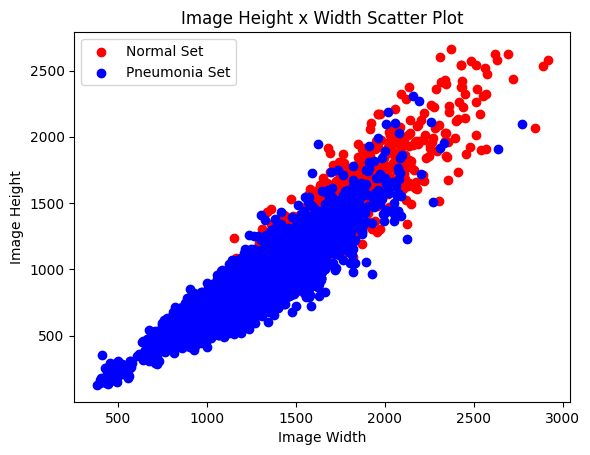

In [26]:
NORMAL_image_heights, NORMAL_image_widths = get_image_sizes('chest_xray/raw/train/NORMAL')
PNEUMONIA_image_heights, PNEUMONIA_image_widths = get_image_sizes('chest_xray/raw/train/PNEUMONIA')
display_size_scatter(NORMAL_image_widths, NORMAL_image_heights, PNEUMONIA_image_widths, PNEUMONIA_image_heights)

From this plot we can see we have images of widely varying resolutions and aspect ratios.

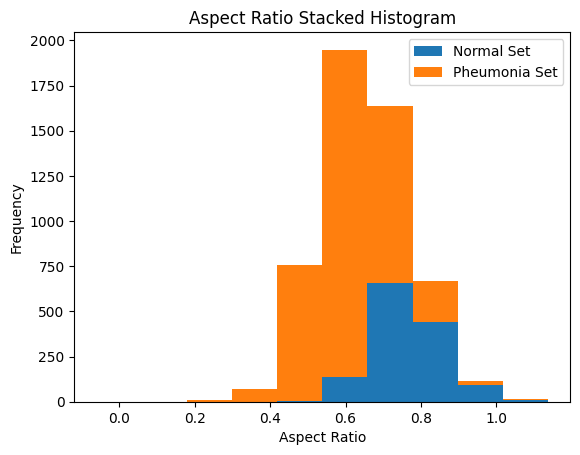

In [27]:
display_aspect_ratio_histogram(NORMAL_image_widths, NORMAL_image_heights, PNEUMONIA_image_widths, PNEUMONIA_image_heights)

The histograms show that the average aspect ratios of the postive and negative images vary slighty. I will take 0.7 as an average of the twoto try preserve the most of the image when cropping.

In [28]:
#rotate_images('./chest_xray/raw/train/NORMAL', './chest_xray/ROTATED/train/NORMAL',)
#rotate_images('./chest_xray/raw/train/PNEUMONIA', './chest_xray/ROTATED/train/PNEUMONIA')
#print("")
#rotate_images('./chest_xray/raw/test/PNEUMONIA', './chest_xray/ROTATED/test/PNEUMONIA')
#rotate_images('./chest_xray/raw/test/NORMAL', './chest_xray/ROTATED/test/NORMAL')
#print("")
#rotate_images('./chest_xray/raw/val/PNEUMONIA', './chest_xray/ROTATED/val/PNEUMONIA')
#rotate_images('./chest_xray/raw/val/NORMAL', './chest_xray/ROTATED/val/NORMAL')

I wanted to rotate images when I initially picked an aspect ratio of 0.7 so I wouldn't crop out as much of the image if it was landscape. This only effected a small ammount of images, approximatly 60. This was made redundant after switching to an aspect ratio of 1.0 and did not improve the training results.

I wrote these pre-processing functions as a reintroduction to work after a long break. On my first attempt I cropped to 0.7 aspect ratio then 595 X 850 resolution trying to keep the most information for training.The resolution was too high resulting in far to many images being discarded. I should have used a better plot to display the sizes of the images as with such a large dataset the scatter with large datapoints does not convay how numerous the data is, only the range. A heatmap or fine grained histogram would be better suited. I decied to do some reading and quickly found common resolutions used for trailing models all of which are 1.0 aspect ratio. I picked 224 X 224 as that matches the input shape used by the models I wanted to use.

In [31]:
crop_image('./chest_xray/raw/train/NORMAL', './chest_xray/CROPPED-1.0/train/NORMAL', aspect_ratio=1.0)
crop_image('./chest_xray/raw/train//PNEUMONIA', './chest_xray/CROPPED-1.0/train/PNEUMONIA', aspect_ratio=1.0)

crop_image('./chest_xray/raw/test/NORMAL', './chest_xray/CROPPED-1.0/test/NORMAL', aspect_ratio=1.0)
crop_image('./chest_xray/raw/test//PNEUMONIA', './chest_xray/CROPPED-1.0/test/PNEUMONIA', aspect_ratio=1.0)

crop_image('./chest_xray/raw/val/NORMAL', './chest_xray/CROPPED-1.0/val/NORMAL', aspect_ratio=1.0)
crop_image('./chest_xray/raw/val//PNEUMONIA', './chest_xray/CROPPED-1.0/val/PNEUMONIA', aspect_ratio=1.0)

In [32]:
resize_image('./chest_xray/CROPPED-1.0/train/NORMAL', './chest_xray/PROCESSED-1.0/train/NORMAL', target_width=224, target_height=224)
resize_image('./chest_xray/CROPPED-1.0/train/PNEUMONIA', './chest_xray/PROCESSED-1.0/train/PNEUMONIA', target_width=224, target_height=224)
print("")
resize_image('./chest_xray/CROPPED-1.0/test/NORMAL', './chest_xray/PROCESSED-1.0/test/NORMAL', target_width=224, target_height=224)
resize_image('./chest_xray/CROPPED-1.0/test/PNEUMONIA', './chest_xray/PROCESSED-1.0/test/PNEUMONIA', target_width=224, target_height=224)
print("")
resize_image('./chest_xray/CROPPED-1.0/val/NORMAL', './chest_xray/PROCESSED-1.0/val/NORMAL', target_width=224, target_height=224)
resize_image('./chest_xray/CROPPED-1.0/val/PNEUMONIA', './chest_xray/PROCESSED-1.0/val/PNEUMONIA', target_width=224, target_height=224)

Discarded 0 images due to size in ./chest_xray/PROCESSED-1.0/train/NORMAL
Discarded 41 images due to size in ./chest_xray/PROCESSED-1.0/train/PNEUMONIA

Discarded 0 images due to size in ./chest_xray/PROCESSED-1.0/test/NORMAL
Discarded 0 images due to size in ./chest_xray/PROCESSED-1.0/test/PNEUMONIA

Discarded 0 images due to size in ./chest_xray/PROCESSED-1.0/val/NORMAL
Discarded 0 images due to size in ./chest_xray/PROCESSED-1.0/val/PNEUMONIA


In [33]:
display_dir_summary('./chest_xray/PROCESSED-1.0/train/NORMAL')
display_dir_summary('./chest_xray/PROCESSED-1.0/train/PNEUMONIA')
print("")
display_dir_summary('./chest_xray/PROCESSED-1.0/test/NORMAL')
display_dir_summary('./chest_xray/PROCESSED-1.0/test/PNEUMONIA')
print("")
display_dir_summary('./chest_xray/PROCESSED-1.0/val/NORMAL')
display_dir_summary('./chest_xray/PROCESSED-1.0/val/PNEUMONIA')

Image size: (224, 224, 3), Count: 1341, Aspect Ratio: 1.0, in ./chest_xray/PROCESSED-1.0/train/NORMAL
Image size: (224, 224, 3), Count: 3834, Aspect Ratio: 1.0, in ./chest_xray/PROCESSED-1.0/train/PNEUMONIA

Image size: (224, 224, 3), Count: 234, Aspect Ratio: 1.0, in ./chest_xray/PROCESSED-1.0/test/NORMAL
Image size: (224, 224, 3), Count: 390, Aspect Ratio: 1.0, in ./chest_xray/PROCESSED-1.0/test/PNEUMONIA

Image size: (224, 224, 3), Count: 8, Aspect Ratio: 1.0, in ./chest_xray/PROCESSED-1.0/val/NORMAL
Image size: (224, 224, 3), Count: 8, Aspect Ratio: 1.0, in ./chest_xray/PROCESSED-1.0/val/PNEUMONIA


https://matplotlib.org/2.0.2/api/pyplot_api.html

https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_stacked.html

https://matplotlib.org/stable/api/matplotlib_configuration_api.html

https://stackoverflow.com/questions/4195453/how-to-resize-an-image-with-opencv2-0-and-python2-6
